# ChemAI: Predict the Cure — EDA

В этом ноутбуке проводится первичный исследовательский анализ данных для задачи предсказания трёх показателей биологической активности химических соединений: `IC50`, `CC50` и `SI`.

Цель EDA:
- понять структуру train/test данных;
- проверить качество данных;
- найти пропуски, дубликаты и возможные проблемы;
- изучить распределения целевых переменных;
- проанализировать признаки;
- подготовить выводы для дальнейшего моделирования.

### Импорты

In [ ]:
!pip install catboost==1.2.10 lightgbm==4.6.0 xgboost==3.2.0 scikit-learn==1.8.0 numpy==2.4.6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb

import re

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import warnings

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

### Загружаем данные

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

TARGET_COLUMNS = ['IC50, mM', 'CC50, mM', 'SI']
targets_sub = ['IC50', 'CC50', 'SI']

## 1. Первичный просмотр данных

Посмотрим размеры таблиц и первые строки `train`, `test` и `sample_submission`. Это нужно, чтобы проверить структуру данных: где находятся признаки, где таргеты и какой формат должен иметь итоговый файл для Kaggle.

In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (751, 214)
Test shape: (250, 211)
Sample submission shape: (250, 4)


In [ ]:
display(train.head())
display(test.head())
display(sample_submission.head())

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


,index,IC50,CC50,SI
0,0,0.723678,0.426328,0.308486
1,1,0.804617,0.643166,0.179750
2,2,0.907425,0.518521,0.298384
3,3,0.563266,0.054770,0.280019
4,4,0.935028,0.616856,0.979752


Вывод:

`train` содержит 751 строку и 214 колонок, `test` — 250 строк и 211 колонок, `sample_submission` — 250 строк и 4 колонки. Разница между `train` и `test` составляет 3 колонки — это целевые переменные `IC50, mM`, `CC50, mM` и `SI`, которые есть только в обучающей выборке.

В `test` присутствуют только `index` и молекулярные признаки. `sample_submission` показывает нужный формат итогового файла: `index`, `IC50`, `CC50`, `SI`. Важно учитывать, что в train таргеты называются `IC50, mM` и `CC50, mM`, а в submission — `IC50` и `CC50`.

## 2. Определение таргетов и признаков

Зафиксируем целевые переменные, служебную колонку `index` и список признаков. Это нужно, чтобы не допустить утечку данных: таргеты и `index` не должны попадать в признаки модели.

In [ ]:
TARGET_COLUMNS = ["IC50, mM", "CC50, mM", "SI"]
ID_COLUMN = "index"

feature_columns = [
    col for col in train.columns
    if col not in TARGET_COLUMNS and col != ID_COLUMN
]

test_feature_columns = [
    col for col in test.columns
    if col != ID_COLUMN
]

print("Target columns:", TARGET_COLUMNS)
print("ID column:", ID_COLUMN)

print("\nКоличество признаков в train:", len(feature_columns))
print("Количество признаков в test:", len(test_feature_columns))
print("Признаки train и test совпадают:", feature_columns == test_feature_columns)

print("\nПервые 10 признаков:")
print(feature_columns[:10])

Target columns: ['IC50, mM', 'CC50, mM', 'SI']
ID column: index

Количество признаков в train: 210
Количество признаков в test: 210
Признаки train и test совпадают: True

Первые 10 признаков:
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']


Вывод:

В качестве целевых переменных используются `IC50, mM`, `CC50, mM` и `SI`. Колонка `index` является служебным идентификатором и не используется как признак.

После исключения таргетов и `index` осталось 210 признаков. Наборы признаков в `train` и `test` совпадают, значит одну и ту же схему обработки можно применять к обеим выборкам.

## 3. Проверка пропусков и бесконечных значений

Проверим наличие пропусков (`NaN`) и бесконечных значений (`inf`, `-inf`). Это важно, потому что многие модели не умеют работать с такими значениями напрямую. Также отдельно проверим таргеты: если пропуски есть в целевых переменных, это серьёзнее, чем пропуски в признаках.

### 3.1. Общее количество пропусков и бесконечных значений

In [ ]:
print("Пропуски в train:", train.isna().sum().sum())
print("Пропуски в test:", test.isna().sum().sum())

print("Пропуски в признаках train:", train[feature_columns].isna().sum().sum())
print("Пропуски в признаках test:", test[feature_columns].isna().sum().sum())

print("\nПропуски в таргетах:")
print(train[TARGET_COLUMNS].isna().sum())

print("\nБесконечные значения в train:")
print(np.isinf(train[feature_columns]).sum().sum())

print("Бесконечные значения в test:")
print(np.isinf(test[feature_columns]).sum().sum())

Пропуски в train: 24
Пропуски в test: 12
Пропуски в признаках train: 24
Пропуски в признаках test: 12

Пропуски в таргетах:
IC50, mM    0
CC50, mM    0
SI          0
dtype: int64

Бесконечные значения в train:
0
Бесконечные значения в test:
0


В данных есть небольшое количество пропусков: 24 значения в `train` и 12 значений в `test`. Все пропуски находятся в признаках, в целевых переменных пропусков нет. Бесконечные значения (`inf`, `-inf`) в признаках не обнаружены.

### 3.2. Признаки и строки с пропусками в train

In [ ]:
missing_by_column = train.isna().sum()

print("Колонки с пропусками в train:")
display(missing_by_column[missing_by_column > 0].sort_values(ascending=False))

rows_with_missing = train[train.isna().any(axis=1)]

print("Количество строк с пропусками в train:", rows_with_missing.shape[0])
display(rows_with_missing[["index"] + missing_by_column[missing_by_column > 0].index.tolist()])

Колонки с пропусками в train:


,0
MaxPartialCharge,2
MinPartialCharge,2
MaxAbsPartialCharge,2
MinAbsPartialCharge,2
BCUT2D_MWHI,2
BCUT2D_MWLOW,2
BCUT2D_CHGHI,2
BCUT2D_CHGLO,2
BCUT2D_LOGPHI,2
BCUT2D_LOGPLOW,2


Количество строк с пропусками в train: 2


,index,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
331,331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В `train` пропуски находятся только в 12 признаках: `MaxPartialCharge`, `MinPartialCharge`, `MaxAbsPartialCharge`, `MinAbsPartialCharge` и группе `BCUT2D_*`. Каждый из этих признаков имеет по 2 пропуска. Пропуски сосредоточены только в двух объектах: `index = 331` и `index = 500`.

### 3.3. Признаки и строки с пропусками в test

In [ ]:
missing_test_by_column = test.isna().sum()

print("Колонки с пропусками в test:")
display(missing_test_by_column[missing_test_by_column > 0].sort_values(ascending=False))

rows_with_missing_test = test[test.isna().any(axis=1)]

print("Количество строк с пропусками в test:", rows_with_missing_test.shape[0])
display(
    rows_with_missing_test[
        ["index"] + missing_test_by_column[missing_test_by_column > 0].index.tolist()
    ]
)

Колонки с пропусками в test:


,0
MaxPartialCharge,1
MinPartialCharge,1
MaxAbsPartialCharge,1
MinAbsPartialCharge,1
BCUT2D_MWHI,1
BCUT2D_MWLOW,1
BCUT2D_CHGHI,1
BCUT2D_CHGLO,1
BCUT2D_LOGPHI,1
BCUT2D_LOGPLOW,1


Количество строк с пропусками в test: 1


,index,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
193,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В `test` пропуски находятся в тех же 12 признаках, что и в `train`, но только у одного объекта: `index = 193`. Так как test-объекты удалять нельзя, для дальнейшего моделирования потребуется обработка пропусков. Базовый вариант — заполнение медианой по признаку.

Вывод:

Данные в целом достаточно чистые: пропусков мало, в целевых переменных они отсутствуют, бесконечных значений нет. Пропуски сосредоточены в ограниченной группе химических дескрипторов. Для дальнейшего моделирования целесообразно использовать заполнение пропусков медианой.

## 4. Проверка дубликатов и типов данных

Проверим, есть ли в данных дубликаты, повторяющиеся `index` и нечисловые признаки. Это нужно, чтобы убедиться, что объекты уникальны, а данные готовы для дальнейшего анализа и моделирования.

### 4.1. Проверка дубликатов

In [ ]:
print("Полные дубликаты в train:", train.duplicated().sum())
print("Полные дубликаты в test:", test.duplicated().sum())

print("Дубликаты index в train:", train[ID_COLUMN].duplicated().sum())
print("Дубликаты index в test:", test[ID_COLUMN].duplicated().sum())

Полные дубликаты в train: 0
Полные дубликаты в test: 0
Дубликаты index в train: 0
Дубликаты index в test: 0


Полные дубликаты строк в `train` и `test` не обнаружены. Значения `index` также не повторяются. Это значит, что каждый объект в выборках имеет уникальный идентификатор.

### 4.2. Проверка типов данных

In [ ]:
print("Типы данных в train:")
print(train.dtypes.value_counts())

print("\nТипы данных в test:")
print(test.dtypes.value_counts())

Типы данных в train:
int64      107
float64    107
Name: count, dtype: int64

Типы данных в test:
int64      107
float64    104
Name: count, dtype: int64


Все колонки имеют числовые типы данных: `int64` или `float64`. Нечисловых признаков нет, поэтому не требуется кодирование категориальных переменных или обработка текстовых данных. Разница в количестве `float64` между `train` и `test` объясняется тем, что в `train` дополнительно находятся три целевые переменные.

Вывод:

Дубликатов в данных нет, `index` уникален, все признаки числовые.

## 5. Анализ целевых переменных

Проанализируем целевые переменные `IC50, mM`, `CC50, mM` и `SI`. Это нужно, чтобы понять масштаб значений, наличие выбросов и возможную необходимость логарифмического преобразования при обучении моделей.

### 5.1. Описательные статистики таргетов

In [ ]:
train[TARGET_COLUMNS].describe()

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


Целевые переменные имеют разные масштабы и выраженную правостороннюю асимметрию. Особенно выделяется `SI`: медиана равна 4, а максимум превышает 15600. Это говорит о наличии сильных выбросов, которые могут заметно влиять на RMSE.

### 5.2. Распределения исходных таргетов

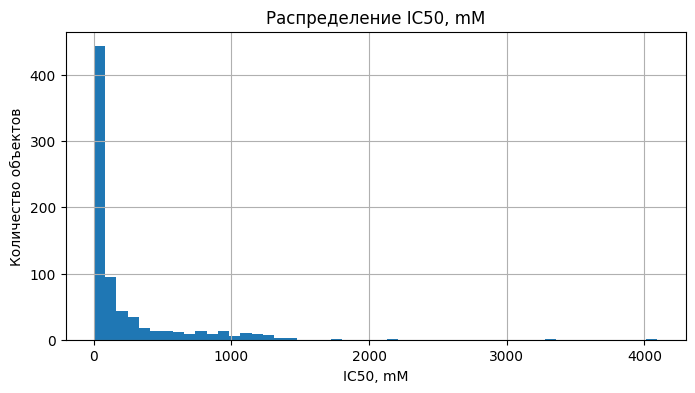

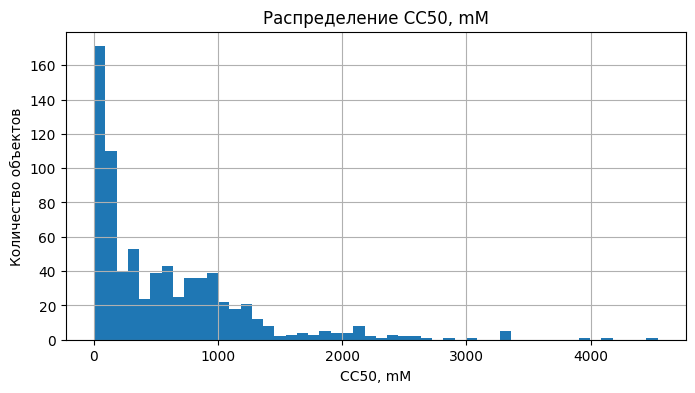

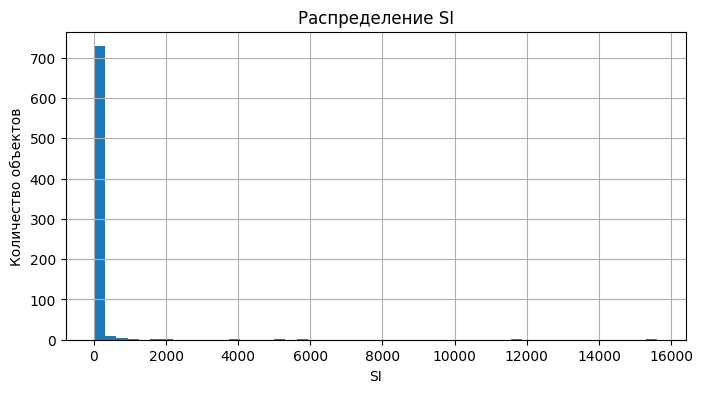

In [ ]:
for col in TARGET_COLUMNS:
    plt.figure(figsize=(8, 4))
    train[col].hist(bins=50)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество объектов")
    plt.show()

Гистограммы подтверждают правостороннюю скошенность таргетов. Основная часть значений находится в малом диапазоне, но есть редкие большие значения. Для `SI` эффект наиболее выражен: из-за экстремальных значений основная масса наблюдений визуально сжата у левого края графика.

### 5.3. Распределения таргетов после log1p-преобразования

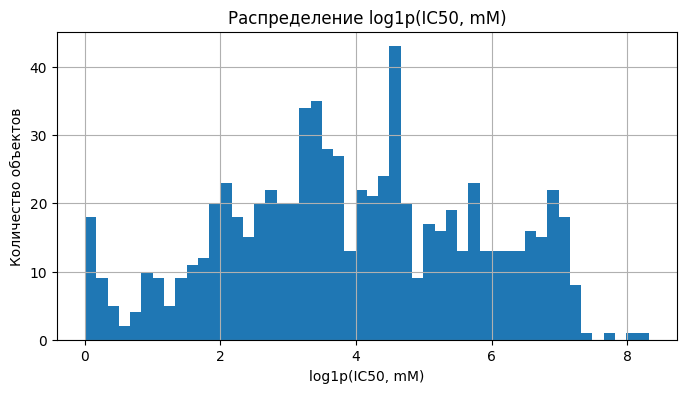

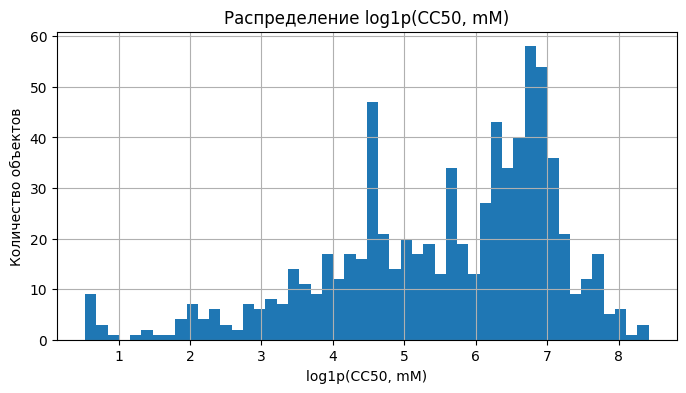

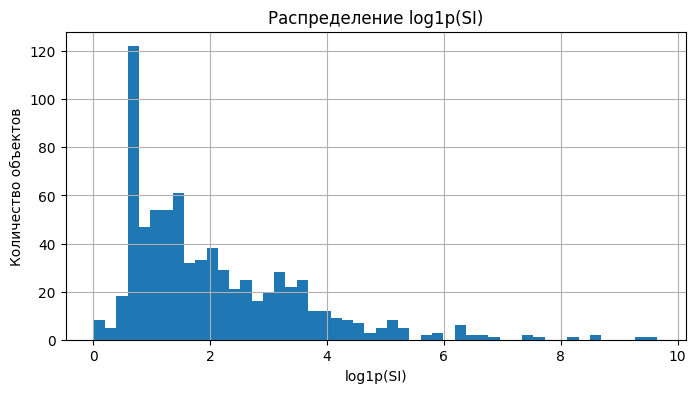

In [ ]:
for col in TARGET_COLUMNS:
    plt.figure(figsize=(8, 4))
    np.log1p(train[col]).hist(bins=50)
    plt.title(f"Распределение log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Количество объектов")
    plt.show()

После `log1p`-преобразования распределения становятся более читаемыми: большие значения сжимаются, а основная масса объектов лучше видна. Это особенно полезно для `SI`, где исходное распределение имеет сильный правый хвост.

Вывод:

Все три целевые переменные имеют правосторонне скошенные распределения и выбросы. Наиболее проблемным является `SI`, у которого максимум значительно выше медианы. Для дальнейшего моделирования стоит сравнить два подхода: обучение на исходных таргетах и обучение на `log1p`-преобразованных таргетах с последующим обратным преобразованием через `expm1`.

## 6. Корреляционный анализ признаков и таргетов

Проверим, какие молекулярные признаки сильнее всего связаны с целевыми переменными. Корреляция помогает быстро оценить простую линейную связь между признаком и таргетом, но не является финальным критерием отбора признаков.

### 6.1. Корреляции всех признаков с таргетами

In [ ]:
correlations_with_targets = (
    train[feature_columns + TARGET_COLUMNS]
    .corr()
    .loc[feature_columns, TARGET_COLUMNS]
)

display(correlations_with_targets.head())

,"IC50, mM","CC50, mM",SI
MaxAbsEStateIndex,0.106600,-0.109807,0.007973
MaxEStateIndex,0.106600,-0.109807,0.007973
MinAbsEStateIndex,-0.100622,0.091942,-0.062446
MinEStateIndex,-0.179369,0.058514,0.025656
qed,0.106424,0.118275,0.044350


Построена таблица корреляций между молекулярными признаками и целевыми переменными. В строках находятся только признаки, а в столбцах — таргеты `IC50, mM`, `CC50, mM` и `SI`, поэтому тривиальные корреляции таргетов самих с собой в анализ не попадают.

### 6.2. Топ-10 признаков по абсолютной корреляции с каждым таргетом

In [ ]:
for target in TARGET_COLUMNS:
    print(f"\nТоп-10 признаков по абсолютной корреляции с {target}:")

    top_corr = (
        correlations_with_targets[target]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    display(
        pd.DataFrame({
            "feature": top_corr.index,
            "abs_correlation": top_corr.values,
            "correlation": correlations_with_targets.loc[top_corr.index, target].values
        })
    )


Топ-10 признаков по абсолютной корреляции с IC50, mM:


,feature,abs_correlation,correlation
0,VSA_EState4,0.244974,-0.244974
1,Chi2n,0.224854,-0.224854
2,Chi2v,0.220377,-0.220377
3,PEOE_VSA7,0.217539,-0.217539
4,Chi4v,0.214185,-0.214185
5,Chi4n,0.211763,-0.211763
6,Chi3v,0.211360,-0.211360
7,Chi3n,0.211065,-0.211065
8,SlogP_VSA5,0.205050,-0.205050
9,Chi1n,0.204975,-0.204975



Топ-10 признаков по абсолютной корреляции с CC50, mM:


,feature,abs_correlation,correlation
0,LabuteASA,0.306634,-0.306634
1,MolMR,0.306621,-0.306621
2,Chi0,0.305092,-0.305092
3,MolWt,0.305003,-0.305003
4,ExactMolWt,0.304977,-0.304977
5,Kappa1,0.304825,-0.304825
6,HeavyAtomCount,0.303823,-0.303823
7,Kappa2,0.302823,-0.302823
8,Chi1,0.302402,-0.302402
9,NumValenceElectrons,0.302281,-0.302281



Топ-10 признаков по абсолютной корреляции с SI:


,feature,abs_correlation,correlation
0,BalabanJ,0.188212,0.188212
1,fr_NH2,0.176325,0.176325
2,RingCount,0.141653,-0.141653
3,fr_Al_COO,0.112759,0.112759
4,fr_COO2,0.110985,0.110985
5,fr_COO,0.110985,0.110985
6,FpDensityMorgan1,0.102769,0.102769
7,VSA_EState4,0.098813,0.098813
8,NumAromaticRings,0.097596,-0.097596
9,VSA_EState6,0.093144,-0.093144


Максимальная абсолютная корреляция признака с `IC50, mM` составляет около 0.245, с `CC50, mM` — около 0.307, с `SI` — около 0.188. Это означает, что отдельные признаки имеют только слабую или умеренную линейную связь с таргетами. Поэтому отбор признаков только по корреляции не должен быть основным методом.

Вывод:

Корреляционный анализ не выявил одного или нескольких признаков, которые сами по себе сильно объясняют целевые переменные. Задача не сводится к простой линейной зависимости от одного дескриптора. Для моделирования стоит использовать методы, способные учитывать нелинейные зависимости и взаимодействия признаков, например RandomForest, Gradient Boosting, CatBoost, XGBoost или LightGBM.

## 7. Константные признаки

Проверим, есть ли признаки, которые имеют только одно уникальное значение. Такие признаки не несут информации для модели, так как не помогают различать химические соединения между собой.

### 7.1. Поиск константных признаков в train

In [ ]:
nunique_train = train[feature_columns].nunique(dropna=False)

constant_features = nunique_train[nunique_train == 1].index.tolist()

print("Количество константных признаков:", len(constant_features))
print(constant_features)

Количество константных признаков: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


В `train` обнаружено 18 константных признаков. Эти признаки имеют только одно уникальное значение и не несут полезной информации для модели.

### 7.2. Проверка этих признаков в test

In [ ]:
print("Константные признаки из train и количество уникальных значений в test:")

test_nunique_for_constant_features = test[constant_features].nunique(dropna=False)

display(
    pd.DataFrame({
        "feature": constant_features,
        "train_unique_values": nunique_train[constant_features].values,
        "test_unique_values": test_nunique_for_constant_features.values
    })
)

Константные признаки из train и количество уникальных значений в test:


,feature,train_unique_values,test_unique_values
0,NumRadicalElectrons,1,1
1,SMR_VSA8,1,1
2,SlogP_VSA9,1,1
3,fr_N_O,1,1
4,fr_SH,1,1
5,fr_azide,1,1
6,fr_barbitur,1,1
7,fr_benzodiazepine,1,1
8,fr_diazo,1,1
9,fr_dihydropyridine,1,1


Все 18 признаков, которые являются константными в `train`, также имеют только одно уникальное значение в `test`. Значит, они не помогают различать объекты ни в обучающей, ни в тестовой выборке.

### 7.3. Формирование списка признаков без константных колонок

In [ ]:
selected_features = [
    col for col in feature_columns
    if col not in constant_features
]

print("Было признаков:", len(feature_columns))
print("Осталось признаков после удаления константных:", len(selected_features))

print("\nУдалённые признаки:")
print(constant_features)

Было признаков: 210
Осталось признаков после удаления константных: 192

Удалённые признаки:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


После удаления 18 константных признаков осталось 192 признака. Далее этот список можно использовать как более чистый набор признаков для анализа и baseline-моделей.

Выводы:

В данных обнаружены 18 константных признаков. Они не меняются ни в `train`, ни в `test`, поэтому не несут информации для модели. Для дальнейшего анализа и моделирования целесообразно использовать список `selected_features`, содержащий 192 признака без константных колонок.

## 8. Сильно коррелирующие признаки между собой

Проверим, есть ли пары признаков, которые сильно коррелируют друг с другом. Такие признаки могут описывать близкие свойства молекулы и частично дублировать информацию.

### 8.1. Поиск пар признаков с корреляцией выше 0.95

In [ ]:
feature_corr = train[selected_features].corr().abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlation"] > 0.95
].sort_values(by="correlation", ascending=False)

print("Количество пар признаков с корреляцией > 0.95:", high_corr_pairs.shape[0])

display(high_corr_pairs.head(30))

Количество пар признаков с корреляцией > 0.95: 91


,feature_1,feature_2,correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
18126,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
16445,fr_COO,fr_COO2,1.000000
14975,NumAromaticCarbocycles,fr_benzene,1.000000
18216,fr_phenol,fr_phenol_noOrthoHbond,1.000000
16333,fr_Ar_NH,fr_Nhpyrrole,1.000000
1132,MolWt,ExactMolWt,0.999999
5527,Chi1,HeavyAtomCount,0.998746
1131,MolWt,HeavyAtomMolWt,0.996985
1316,HeavyAtomMolWt,ExactMolWt,0.996955


Найдено 91 пара признаков с корреляцией выше 0.95. Это говорит о наличии избыточности в данных: часть молекулярных дескрипторов описывает близкие свойства соединений.

### 8.2. Примеры сильно коррелирующих признаков

Среди сильно коррелирующих признаков есть пары, связанные с молекулярной массой (`MolWt`, `ExactMolWt`, `HeavyAtomMolWt`), размером молекулы (`HeavyAtomCount`, `Chi0`, `Chi1`, `LabuteASA`) и функциональными группами (`fr_COO`, `fr_COO2`). Это ожидаемо для химических дескрипторов, так как разные признаки могут описывать похожие структурные свойства.

Выводы:

В данных есть группы сильно коррелирующих дескрипторов. Для древесных моделей и бустингов это не является критичной проблемой, так как такие модели могут работать с избыточными признаками. Однако для линейных моделей или интерпретации результатов может быть полезно проверить отдельную гипотезу с удалением одного признака из сильно коррелирующих пар.

## 9. Сравнение распределений признаков в train и test

Проверим, похожи ли обучающая и тестовая выборки по распределениям признаков. Если test сильно отличается от train, модель может хуже обобщаться на тестовые объекты.

### 9.1. Сравнение средних значений признаков

In [ ]:
train_feature_stats = train[selected_features].describe().T
test_feature_stats = test[selected_features].describe().T

distribution_shift = pd.DataFrame({
    "train_mean": train_feature_stats["mean"],
    "test_mean": test_feature_stats["mean"],
    "train_std": train_feature_stats["std"],
    "test_std": test_feature_stats["std"],
})

distribution_shift["mean_abs_diff"] = (
    distribution_shift["train_mean"] - distribution_shift["test_mean"]
).abs()

distribution_shift_sorted = distribution_shift.sort_values(
    by="mean_abs_diff",
    ascending=False
)

display(distribution_shift_sorted.head(20))

,train_mean,test_mean,train_std,test_std,mean_abs_diff
Ipc,6.327782e+10,3.374804e+09,1.449887e+12,2.506582e+10,5.990302e+10
BertzCT,7.656501e+02,7.189619e+02,4.493009e+02,3.917101e+02,4.668820e+01
MolWt,3.524073e+02,3.358103e+02,1.290712e+02,1.197249e+02,1.659702e+01
ExactMolWt,3.520813e+02,3.355018e+02,1.289249e+02,1.196121e+02,1.657951e+01
HeavyAtomMolWt,3.283898e+02,3.126908e+02,1.240724e+02,1.136784e+02,1.569900e+01
LabuteASA,1.484664e+02,1.413320e+02,5.325094e+01,5.006463e+01,7.134416e+00
NumValenceElectrons,1.336272e+02,1.275760e+02,4.717366e+01,4.504237e+01,6.051164e+00
MolMR,9.538475e+01,9.059714e+01,3.480489e+01,3.309866e+01,4.787601e+00
SMR_VSA7,3.858819e+01,3.502287e+01,3.252938e+01,2.904700e+01,3.565319e+00
SlogP_VSA6,3.167385e+01,2.834146e+01,2.583587e+01,2.295463e+01,3.332389e+00


По абсолютной разнице средних сильнее всего выделяется признак `Ipc`, однако у него очень большой масштаб и большое стандартное отклонение. Поэтому абсолютная разница средних не всегда корректно отражает реальный сдвиг распределений.

### 9.2. Нормированная разница средних

In [ ]:
distribution_shift["mean_diff_normalized"] = (
    (distribution_shift["train_mean"] - distribution_shift["test_mean"]).abs()
    / distribution_shift["train_std"].replace(0, np.nan)
)

distribution_shift_normalized = distribution_shift.sort_values(
    by="mean_diff_normalized",
    ascending=False
)

display(distribution_shift_normalized.head(20))

,train_mean,test_mean,train_std,test_std,mean_abs_diff,mean_diff_normalized
fr_oxazole,0.001332,0.012000,0.036491,0.109104,0.010668,0.292362
fr_epoxide,0.002663,0.012000,0.051571,0.141194,0.009337,0.181049
BCUT2D_LOGPLOW,-2.410229,-2.383235,0.175473,0.180499,0.026994,0.153835
RingCount,3.620506,3.388000,1.603681,1.474501,0.232506,0.144983
EState_VSA7,14.698201,11.705727,20.955166,16.239009,2.992475,0.142804
MolMR,95.384745,90.597144,34.804886,33.098655,4.787601,0.137555
Kappa2,6.482013,6.063237,3.061584,2.809564,0.418775,0.136784
Chi1n,8.745933,8.320018,3.132727,3.131125,0.425915,0.135957
Chi1,11.881581,11.271647,4.501564,4.192200,0.609933,0.135494
Chi1v,9.046804,8.609390,3.233148,3.201428,0.437414,0.135290


После нормировки на стандартное отклонение максимальная разница средних составляет около 0.29 стандартного отклонения. Это говорит о том, что выраженного сдвига между train и test по признакам не наблюдается.

Выводы:

Train и test в целом похожи по распределениям признаков. Сильного сдвига между обучающей и тестовой выборками не обнаружено. Это хороший признак для моделирования: модель будет применяться к объектам, похожим на те, на которых она обучалась.

## 10. Анализ выбросов в признаках

Проверим, есть ли среди признаков выраженные выбросы и длинные правые хвосты. Это важно, потому что признаки с очень разными масштабами могут влиять на линейные модели, масштабирование и интерпретацию результатов.

### 10.1. Сравнение медианы и 99-го процентиля

In [ ]:
feature_quantiles = train[selected_features].quantile([0.5, 0.95, 0.99]).T

feature_quantiles.columns = ["median", "p95", "p99"]

feature_quantiles["p99_to_median_ratio"] = (
    feature_quantiles["p99"].abs() / feature_quantiles["median"].replace(0, np.nan).abs()
)

feature_quantiles_sorted = feature_quantiles.sort_values(
    by="p99_to_median_ratio",
    ascending=False
)

display(feature_quantiles_sorted.head(20))

,median,p95,p99,p99_to_median_ratio
Ipc,119977.905630,1.060310e+10,2.282400e+11,1.902350e+06
VSA_EState3,4.007098,3.178187e+01,9.098108e+01,2.270498e+01
EState_VSA7,4.899910,5.899248e+01,8.260843e+01,1.685917e+01
EState_VSA1,5.601051,4.561052e+01,8.782124e+01,1.567942e+01
PEOE_VSA10,5.693928,2.879621e+01,7.094554e+01,1.245986e+01
VSA_EState1,6.484838,5.016551e+01,7.093708e+01,1.093891e+01
EState_VSA10,5.106527,2.817884e+01,5.075328e+01,9.938904e+00
EState_VSA5,12.841643,5.136657e+01,1.205536e+02,9.387705e+00
NHOHCount,1.000000,4.000000e+00,9.000000e+00,9.000000e+00
NumHDonors,1.000000,4.000000e+00,9.000000e+00,9.000000e+00


У части признаков наблюдаются длинные правые хвосты. Самый заметный пример — `Ipc`: его 99-й процентиль значительно выше медианы. Также выраженные хвосты есть у ряда VSA/EState-дескрипторов.

Выводы:

Некоторые молекулярные дескрипторы имеют сильный разброс и редкие большие значения. Для древесных моделей и бустингов это обычно не является критичной проблемой, но для линейных моделей может потребоваться масштабирование, логарифмирование отдельных признаков или робастная обработка выбросов.

## 11. Итоговые выводы EDA

### 11.1. Краткое резюме анализа

1. `train` содержит 751 объект и 214 колонок, `test` — 250 объектов и 211 колонок.
2. После исключения `index` и трёх таргетов доступно 210 молекулярных признаков.
3. Наборы признаков в `train` и `test` совпадают.
4. Все признаки числовые, категориальные и текстовые признаки отсутствуют.
5. В данных есть небольшое количество пропусков:
   - 24 значения в `train`;
   - 12 значений в `test`.
6. Пропуски находятся только в признаках, в таргетах пропусков нет.
7. Пропуски сосредоточены в дескрипторах `PartialCharge` и `BCUT2D`.
8. Полные дубликаты и дубликаты `index` не обнаружены.
9. Целевые переменные имеют правосторонне скошенные распределения.
10. Особенно сильные выбросы наблюдаются у `SI`.
11. `log1p`-преобразование делает распределения таргетов более читаемыми и может быть проверено как ML-гипотеза.
12. Найдено 18 константных признаков.
13. После удаления константных признаков остаётся 192 признака.
14. В данных есть избыточность: найдено 91 пара признаков с корреляцией выше 0.95.
15. Сильного сдвига между `train` и `test` по признакам не обнаружено.
16. Некоторые признаки, например `Ipc` и VSA/EState-дескрипторы, имеют длинные правые хвосты.

### 11.2. Что это означает для дальнейшего моделирования

1. Использовать `index` только для формирования submission, но не как признак модели.
2. Исключить из признаков таргеты `IC50, mM`, `CC50, mM`, `SI`.
3. Заполнять пропуски медианой по признаку.
4. Проверить baseline на 192 признаках после удаления константных колонок.
5. Сравнить обучение на исходных таргетах и на `log1p`-преобразованных таргетах.
6. Использовать древесные модели и бустинги как основные кандидаты: RandomForest, Gradient Boosting, CatBoost, XGBoost, LightGBM.
7. Не выбирать признаки только по корреляции с таргетом, так как линейные связи слабые.
8. Проверить отдельные гипотезы отбора признаков: top-N по feature importance, удаление сильно коррелирующих признаков, permutation importance.

Выводы:

Датасет подходит для классической задачи табличной регрессии по числовым молекулярным дескрипторам. Основные проблемы данных — пропуски в небольшой группе признаков, константные колонки, избыточность признаков и выбросы в таргетах. Для первого решения целесообразно использовать медианное заполнение пропусков, удаление константных признаков и модели, устойчивые к нелинейным зависимостям.

## 12. Предобработка данных

Очистка, нормализация, а также выбор и создание соответствующих признаков. Удаляются выбросы (SI > 2000) и целевые столбцы; названия признаков очищаются регулярным выражением. Далее убираются константные признаки и высококоррелированные пары (r > 0.95), чтобы снизить мультиколлинеарность.

In [ ]:
train = train[train['SI'] < 2000].reset_index(drop=True)

targets_train = ['IC50, mM', 'CC50, mM', 'SI']
targets_sub = ['IC50', 'CC50', 'SI']

X = train.drop(columns=['index'] + targets_train)
X_test = test.drop(columns=['index'])

X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
X_test = X_test.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

constant_features = [col for col in X.columns if X[col].std() == 0]
X = X.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)

In [ ]:
print("корреляция > 0.95...")
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)
print(f"Осталось базовых признаков: {X.shape[1]}")

In [ ]:
# функция для расчета RMSE
def calc_rmse(y_true, y_pred, is_log):
    if is_log:
        y_true_real = np.expm1(y_true)
        y_pred_real = np.clip(np.expm1(y_pred), 0, None)
    else:
        y_true_real = y_true
        y_pred_real = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(y_true_real, y_pred_real))

## Выбор модели

На этом этапе мы определяем, какая модель регрессии лучше всего подходит для нашей задачи.

Задается список сидов (`SEEDS`), где алгоритмы будут обучаться три полных раза, каждый раз по-разному перемешивая данные и инициализируя деревья. Итоговые предсказания будут усреднены. Количество фолдов (`n_splits`) = 10, здесь строгая 10-фолдовая кросс-валидация. Также задаются словари гиперпараметров для трёх градиентных бустингов (CatBoost, LightGBM, XGBoost) отдельно для каждого целевого признака (IC50, CC50, SI). В submission мы заранее создаем заготовку для финального файла, сразу копируя колонку index из тестовой выборки.

In [ ]:
submission = pd.DataFrame({'index': test['index']})
SEEDS = [42, 2024, 7]
n_splits = 10
multi_seed_predictions = {'IC50': [], 'CC50': [], 'SI': []}

cb_params = {
    'IC50': {'iterations': 1500, 'learning_rate': 0.02, 'depth': 6, 'l2_leaf_reg': 5.0, 'subsample': 0.8},
    'CC50': {'iterations': 1700, 'learning_rate': 0.02, 'depth': 5,
         'l2_leaf_reg': 7.7, 'subsample': 0.5,
         'border_count': 83, 'min_data_in_leaf': 18,
         'random_strength': 1.8},
    'SI':   {'iterations': 2000, 'learning_rate': 0.03, 'depth': 5, 'l2_leaf_reg': 3.0, 'subsample': 0.9},
}

lgb_params = {
    'IC50': {'n_estimators': 1500, 'learning_rate': 0.02, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8},
    'CC50': {'n_estimators': 2500, 'learning_rate': 0.005, 'max_depth': 7,
         'subsample': 0.8, 'colsample_bytree': 0.64,
         'num_leaves': 15, 'min_child_samples': 11,
         'reg_alpha': 0.006, 'reg_lambda': 0.012},
    'SI':   {'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9},
}

xgb_params = {
    'IC50': {'n_estimators': 2000, 'learning_rate': 0.02, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'},
        'CC50': {'n_estimators': 2500, 'learning_rate': 0.005, 'max_depth': 7,
         'subsample': 0.8, 'colsample_bytree': 0.64,
         'num_leaves': 15, 'min_child_samples': 11,
         'reg_alpha': 0.006, 'reg_lambda': 0.012},
    'SI':   {'n_estimators': 2500, 'learning_rate': 0.03, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9, 'tree_method': 'hist'}
}

## Обучение моделей (Stacking)

На данном этапе происходит использование тренировочного набора данных для подгонки модели, т.е. определения её параметров. Для каждого сида и каждого таргета запускается двухуровневый стекинг: базовые модели (CatBoost, LightGBM, XGBoost) обучаются через 10-кратную кросс-валидацию, а Ridge-регрессия на OOF-предсказаниях формирует финальный сигнал для теста.

**Пайплайн разделен на два уровня обучения:**

Уровень 1: Мы обучаем три разных алгоритма градиентного бустинга (CatBoost, LightGBM, XGBoost).

Во время K-Fold кросс-валидации каждая модель делает предсказания для той части данных, которую она не видела при обучении (Out-Of-Fold или OOF предсказания).

Уровень 2: Мы берем  OOF-предсказания от бустингов и используем их как новые признаки (колонки) для простой линейной модели — Ridge (Гребневая регрессия).

Ridge-регрессия смотрит на ответы базовых моделей и учится понимать, кому из них доверять больше в конкретных ситуациях. Если LightGBM нашел ложную закономерность и сильно ошибся на молекуле, но CatBoost и XGBoost дали адекватный ответ, Ridge-регрессия сгладит этот выброс.

In [ ]:
for SEED in SEEDS:
    print(f"\n--- Seed: {SEED} ")

    for train_col, sub_col in zip(targets_train, targets_sub):

        apply_log = (sub_col == 'SI')
        print(f"\nОбучение для: {sub_col} {'(Log-Space)' if apply_log else '(Raw-Space)'}")

        y_raw = train[train_col]
        y = np.log1p(y_raw) if apply_log else y_raw

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

        oof_cb = np.zeros(len(train))
        oof_lgb = np.zeros(len(train))
        oof_xgb = np.zeros(len(train))

        test_cb = np.zeros(len(test))
        test_lgb = np.zeros(len(test))
        test_xgb = np.zeros(len(test))

        # Обучение базовых моделей
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]


            model_cb = CatBoostRegressor(**cb_params[sub_col], random_seed=SEED, verbose=0)
            model_cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100)
            oof_cb[val_idx] = model_cb.predict(X_va)
            test_cb += model_cb.predict(X_test) / n_splits

            model_lgb = lgb.LGBMRegressor(**lgb_params[sub_col], random_state=SEED, n_jobs=-1, verbose=-1)
            model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(100, verbose=False)])
            oof_lgb[val_idx] = model_lgb.predict(X_va)
            test_lgb += model_lgb.predict(X_test) / n_splits

            model_xgb = xgb.XGBRegressor(**xgb_params[sub_col], random_state=SEED, early_stopping_rounds=100, n_jobs=-1)
            model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            oof_xgb[val_idx] = model_xgb.predict(X_va)
            test_xgb += model_xgb.predict(X_test) / n_splits

        print(f"  RMSE CatBoost: {calc_rmse(y, oof_cb, apply_log):.4f}")
        print(f"  RMSE LightGBM: {calc_rmse(y, oof_lgb, apply_log):.4f}")
        print(f"  RMSE XGBoost:  {calc_rmse(y, oof_xgb, apply_log):.4f}")

        # Стеккинг

        X_meta_train = np.column_stack([oof_cb, oof_lgb, oof_xgb])
        X_meta_test = np.column_stack([test_cb, test_lgb, test_xgb])


        meta_model = Ridge(alpha=1.0)
        meta_model.fit(X_meta_train, y)

        meta_oof_preds = meta_model.predict(X_meta_train)
        seed_final_preds = meta_model.predict(X_meta_test)

        print(f" Стекинг RMSE: {calc_rmse(y, meta_oof_preds, apply_log):.4f}")

        # Обратное преобразование и клиппинг
        if apply_log:
            seed_final_preds = np.clip(np.expm1(seed_final_preds), 0, None)
        else:
            seed_final_preds = np.clip(seed_final_preds, 0, None)

        multi_seed_predictions[sub_col].append(seed_final_preds)

В реальной ситуации поддерживать трехслойный ансамбль из разных библиотек очень тяжело. Обучить такой пайплайн стоит дорого по времени. Так как мы используем 3  алгоритма по 10 фолдам на 3 разных сидах.

Мы используем фильтр коллинеарности Пирсона (удаляем корреляцию > 0.95). Это может случайно выбросить дескриптор, который имеет важную нелинейную связь с токсичностью или эффективностью молекулы.

## Формирование сабмита

Предсказания по всем сидам усредняются методом ансамблирования. Применяется мягкий клиппинг по 99.9-му перцентилю тренировочных данных, после чего результирующий датафрейм сохраняется в файл `submission.csv`.

In [ ]:
for col in targets_sub:
    submission[col] = np.mean(multi_seed_predictions[col], axis=0)

# клиппинг по 99.9 процентилю
for col_sub, col_train in zip(targets_sub, targets_train):
    upper_bound = train[col_train].quantile(0.999)
    submission[col_sub] = np.clip(submission[col_sub], 0, upper_bound)

In [ ]:
submission.to_csv('submission.csv', index=False)